# Shubhwani Yadav

# Data Analytics

## TASK 1 · EDA on Retail Sales Data 
Objective: Perform a thorough Exploratory Data Analysis on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights. 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)

### 1. Load Dataset & Initial Inspection

We start by loading the data and checking its shape, column types, and missing values — this tells us how much cleaning is needed before any analysis.


In [3]:
df = pd.read_csv("retail_sales_data.csv", parse_dates=["OrderDate"])
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (9815, 16)


,OrderID,OrderDate,CustomerID,CustomerAge,Gender,Region,ProductCategory,ProductName,UnitPrice,Quantity,DiscountPct,Sales,Cost,Profit,PaymentMode,CustomerRating
0,ORD106119,2023-01-01,CUST3029,33.0,Female,South,Home & Kitchen,Air Fryer,964.96,1,0.002,963.03,657.72,305.31,Debit Card,5.0
1,ORD105481,2023-01-01,CUST3013,27.0,Other,South,Electronics,Laptop Stand,2360.64,1,0.027,2296.90,1405.37,891.53,Debit Card,4.0
2,ORD107030,2023-01-01,CUST1326,42.0,Male,North,Beauty & Personal Care,Face Serum,1590.73,4,0.009,6305.65,4530.56,1775.09,UPI,3.0
3,ORD103452,2023-01-01,CUST2834,26.0,Female,West,Furniture,Bookshelf,3079.23,2,0.029,5979.86,3632.61,2347.25,UPI,1.0
4,ORD105539,2023-01-01,CUST2966,20.0,Female,South,Home & Kitchen,Non-stick Pan,3861.41,4,0.013,15244.85,10589.56,4655.29,Cash on Delivery,3.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9815 entries, 0 to 9814
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          9815 non-null   object        
 1   OrderDate        9815 non-null   datetime64[ns]
 2   CustomerID       9815 non-null   object        
 3   CustomerAge      9714 non-null   float64       
 4   Gender           9815 non-null   object        
 5   Region           9795 non-null   object        
 6   ProductCategory  9815 non-null   object        
 7   ProductName      9815 non-null   object        
 8   UnitPrice        9815 non-null   float64       
 9   Quantity         9815 non-null   int64         
 10  DiscountPct      9815 non-null   float64       
 11  Sales            9815 non-null   float64       
 12  Cost             9815 non-null   float64       
 13  Profit           9815 non-null   float64       
 14  PaymentMode      9815 non-null   object 

In [5]:
print("Column data types:\n")
print(df.dtypes)

print("\nMissing values per column:\n")
print(df.isnull().sum())

print("\nMissing value % per column:\n")
print((df.isnull().mean() * 100).round(2))


Column data types:

OrderID                    object
OrderDate          datetime64[ns]
CustomerID                 object
CustomerAge               float64
Gender                     object
Region                     object
ProductCategory            object
ProductName                object
UnitPrice                 float64
Quantity                    int64
DiscountPct               float64
Sales                     float64
Cost                      float64
Profit                    float64
PaymentMode                object
CustomerRating            float64
dtype: object

Missing values per column:

OrderID              0
OrderDate            0
CustomerID           0
CustomerAge        101
Gender               0
Region              20
ProductCategory      0
ProductName          0
UnitPrice            0
Quantity             0
DiscountPct          0
Sales                0
Cost                 0
Profit               0
PaymentMode          0
CustomerRating     153
dtype: int64

Missing val

**Observation:** The dataset has ~9,800 transaction-level records across 16 columns spanning two full years (2023–2024). A small number of missing values exist in `Region`, `CustomerAge`, and `CustomerRating` — small enough (<2%) that we can either drop or impute them without materially affecting the analysis. There are also a handful of exact duplicate rows to check for.



### Check & handle duplicates

In [25]:
dupe_count = df.duplicated().sum()
print(f"Exact duplicate rows: {dupe_count}")
df = df.drop_duplicates().reset_index(drop=True)

# Simple, defensible cleaning choices:
df["Region"] = df["Region"].fillna("Unknown")
df["CustomerAge"] = df["CustomerAge"].fillna(df["CustomerAge"].median())
print("Shape after cleaning:", df.shape)

Exact duplicate rows: 0
Shape after cleaning: (9800, 21)


##### **Observation:** 
After removing exact duplicates and filling small gaps in `Region` (unknown category) and `CustomerAge` (median imputation), the dataset is clean enough for reliable analysis.We deliberately did **not** impute `CustomerRating`, since fabricating satisfaction scores could bias that specific analysis— we'll just exclude nulls when we get there.


## 2. Descriptive Statistics

Mean, median, mode, and standard deviation for every numerical column give us a first read on typical order size, spread, and skew.


In [8]:
num_cols = ["CustomerAge", "UnitPrice", "Quantity", "DiscountPct", "Sales", "Cost", "Profit", "CustomerRating"]
desc = df[num_cols].describe().T
desc["mode"] = df[num_cols].mode().iloc[0]
desc["skew"] = df[num_cols].skew()
desc = desc[["mean", "50%", "mode", "std", "min", "max", "skew"]]
desc.columns = ["mean", "median", "mode", "std_dev", "min", "max", "skew"]
desc.round(2)


,mean,median,mode,std_dev,min,max,skew
CustomerAge,33.94,34.00,16.00,10.57,16.00,75.00,0.29
UnitPrice,2274.60,1679.18,218.96,1847.22,51.42,8999.29,1.39
Quantity,1.55,1.00,1.00,0.92,1.00,5.00,1.92
DiscountPct,0.03,0.02,0.00,0.04,0.00,0.41,2.96
Sales,3429.16,2106.28,1721.77,3797.24,49.42,41390.44,3.06
Cost,2299.20,1416.72,1062.72,2566.94,29.94,32128.45,3.14
Profit,1129.96,692.90,173.17,1295.10,-805.41,14916.33,3.27
CustomerRating,3.62,4.00,4.00,0.91,1.00,5.00,-0.22


##### **Observation:**
- Average order value (`Sales`) sits noticeably above the median, and the positive skew confirms a typical retail pattern: most orders are modest, but a smaller number of high-value orders pull the average up.
- `DiscountPct` is right-skewed — most transactions carry little or no discount, with occasional deep discounts (consistent with seasonal sales).
- `Profit` has a wide standard deviation relative to its mean, suggesting margins vary a lot by category/discount level rather than being uniformly consistent — worth digging into during the product analysis.


### 3. Time Series Analysis — Monthly & Quarterly Sales Trends


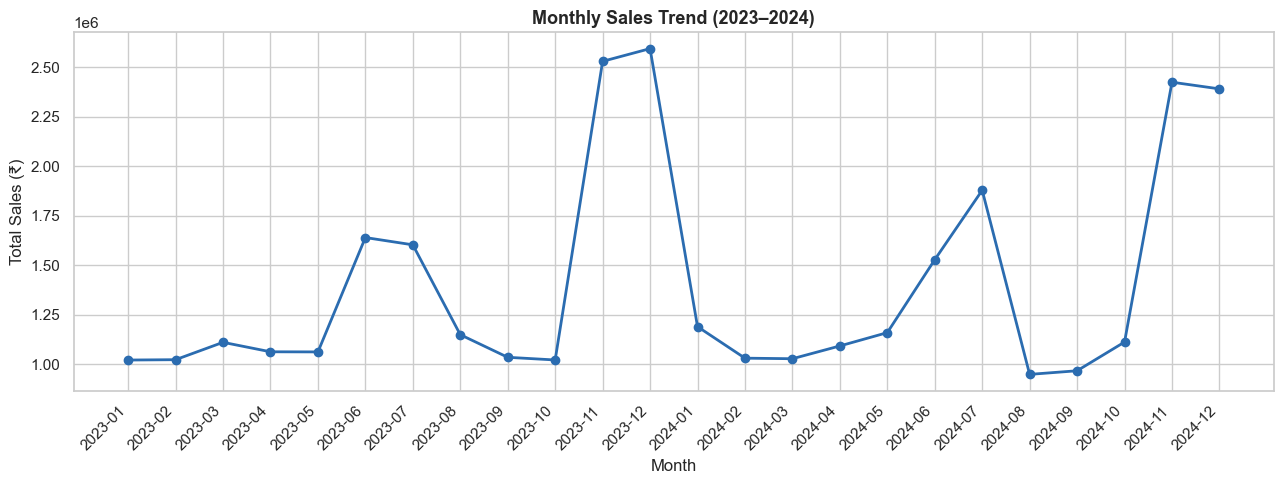

In [9]:
df["YearMonth"] = df["OrderDate"].dt.to_period("M").astype(str)
df["YearQuarter"] = df["OrderDate"].dt.to_period("Q").astype(str)

monthly_sales = df.groupby("YearMonth")["Sales"].sum().reset_index()

plt.figure(figsize=(13, 5))
plt.plot(monthly_sales["YearMonth"], monthly_sales["Sales"], marker="o", linewidth=2, color="#2b6cb0")
plt.xticks(rotation=45, ha="right")
plt.title("Monthly Sales Trend (2023–2024)")
plt.xlabel("Month")
plt.ylabel("Total Sales (₹)")
plt.tight_layout()
plt.show()


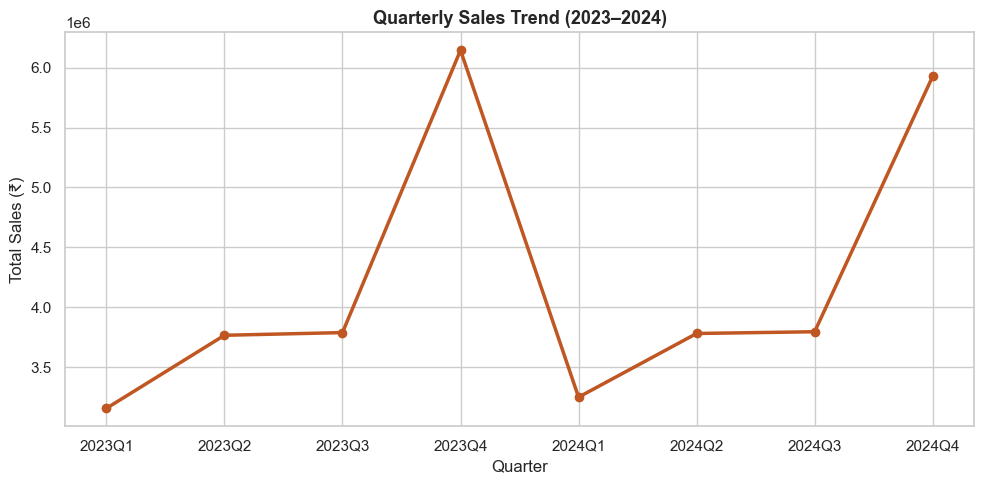

In [10]:
quarterly_sales = df.groupby("YearQuarter")["Sales"].sum().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(quarterly_sales["YearQuarter"], quarterly_sales["Sales"], marker="o", linewidth=2.5, color="#c05621")
plt.title("Quarterly Sales Trend (2023–2024)")
plt.xlabel("Quarter")
plt.ylabel("Total Sales (₹)")
plt.tight_layout()
plt.show()


##### **Observation:** 
Sales show a clear seasonal pattern — a strong spike around **November–December** in both years (holiday/year-end shopping) and a secondary bump around **June–July** (mid-year sale period). The quarterly view confirms **Q4 is consistently the strongest quarter**, which has direct implications for inventory planning and staffing.


### 4. Customer Demographics Analysis


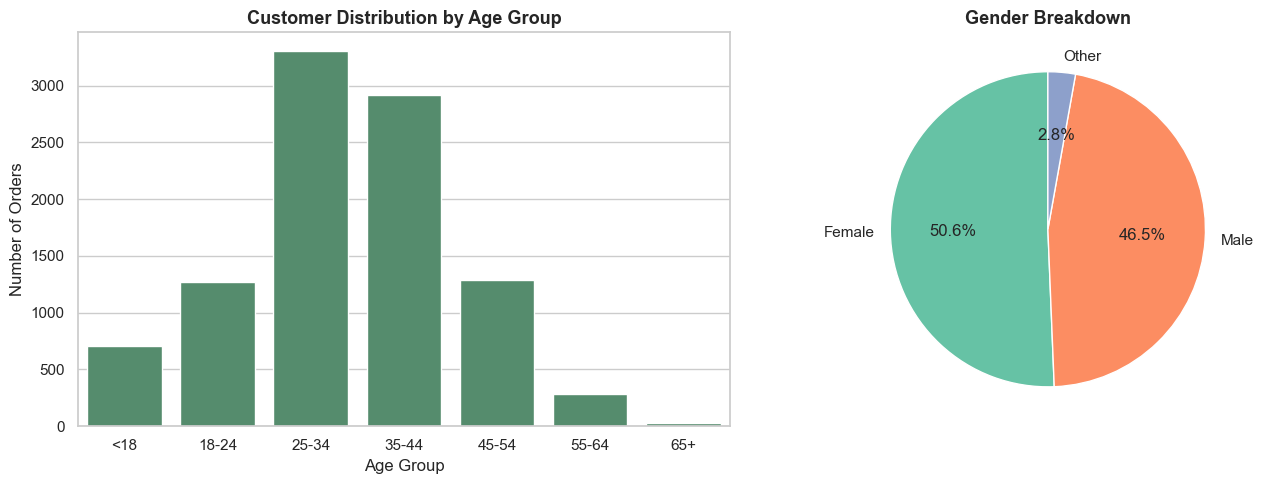

In [11]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ["<18", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
df["AgeGroup"] = pd.cut(df["CustomerAge"], bins=bins, labels=labels, right=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_counts = df["AgeGroup"].value_counts().sort_index()
sns.barplot(x=age_counts.index, y=age_counts.values, ax=axes[0], color="#4c956c")
axes[0].set_title("Customer Distribution by Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Number of Orders")

gender_counts = df["Gender"].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2"), startangle=90)
axes[1].set_title("Gender Breakdown")

plt.tight_layout()
plt.show()


##### **Observation:** 
The customer base skews toward the **25–44 age range**, which together accounts for the largest share of orders — this is likely the core target demographic for marketing spend. Gender split is fairly balanced between male and female customers, with a small "Other" segment; campaigns likely don't need heavy gender-based segmentation but could still be tailored to the dominant 25–44 age band.


### 5. Product Analysis — Best Sellers & Category Revenue


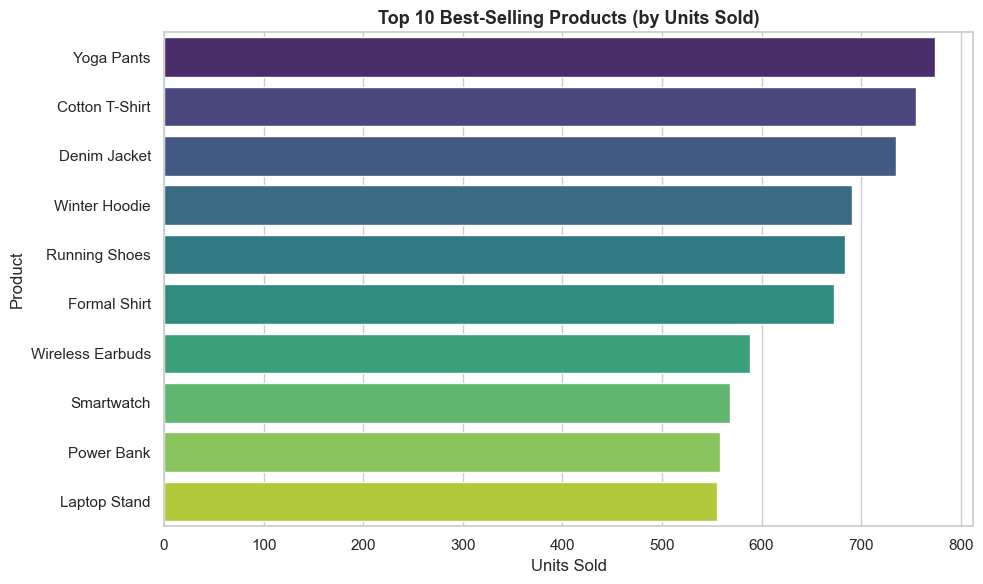

In [12]:
top_products = df.groupby("ProductName")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette="viridis", legend=False)
plt.title("Top 10 Best-Selling Products (by Units Sold)")
plt.xlabel("Units Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


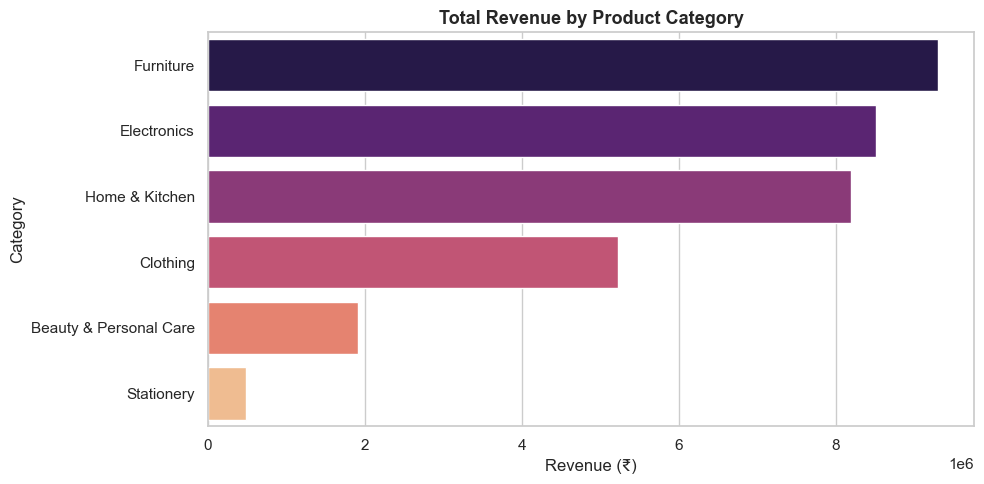

In [13]:
category_revenue = df.groupby("ProductCategory")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=category_revenue.values, y=category_revenue.index, hue=category_revenue.index, palette="magma", legend=False)
plt.title("Total Revenue by Product Category")
plt.xlabel("Revenue (₹)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


##### **Observation:** 
A small handful of high-frequency, lower-priced products (e.g. clothing and stationery items) dominate **units sold**, while **revenue** is more concentrated in a different set of categories with higher unit prices (Electronics, Furniture) despite lower order volume. This unit-volume vs. revenue mismatch is a classic sign that bestseller lists and top-revenue lists shouldn't be treated as the same thing when planning promotions.


### 6. Correlation Matrix — Numerical Variables


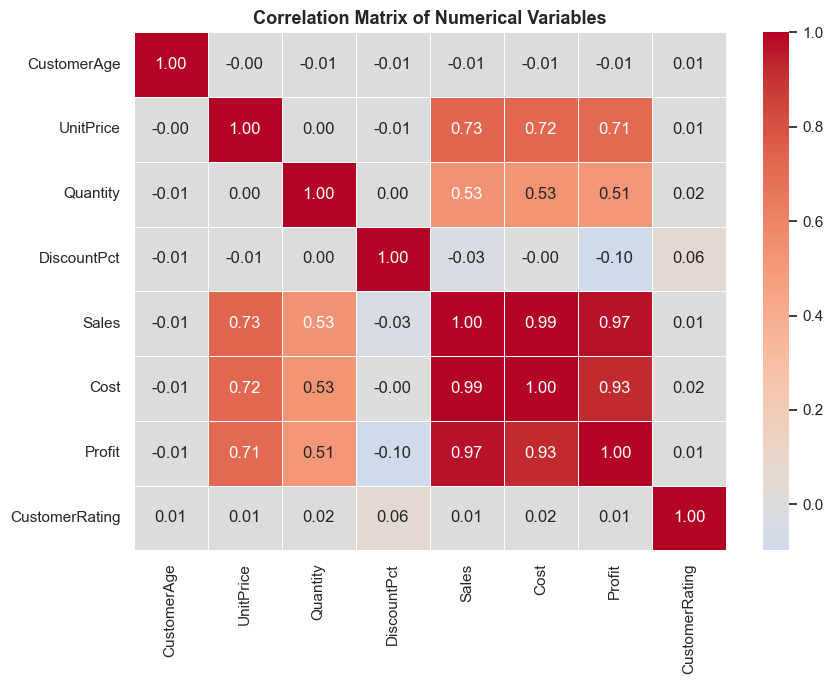

In [14]:
corr_cols = ["CustomerAge", "UnitPrice", "Quantity", "DiscountPct", "Sales", "Cost", "Profit", "CustomerRating"]
corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()


##### **Observation:** 
`Sales`, `Cost`, and `Profit` are strongly correlated with each other (expected, since profit is derived from them). More interestingly, `DiscountPct` shows a **negative correlation with Profit** — confirming that heavier discounting erodes margin faster than it drives enough extra volume to compensate, at least in aggregate. `CustomerAge` and `CustomerRating` show negligible correlation with the financial variables, suggesting satisfaction and spending are driven more by product/category factors than by customer age.


### 7. Additional Insight — Discount Depth vs. Profit Margin by Category

Beyond the required charts, it's worth checking whether the discount-vs-profit relationship we saw in the heatmap holds **uniformly across categories**, or whether some categories can absorb discounts better than others.


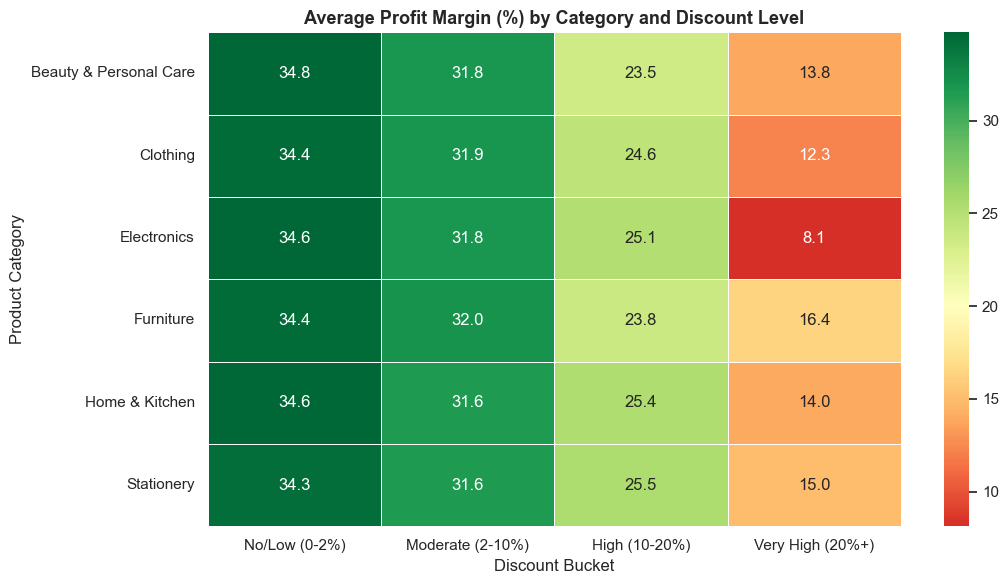

In [15]:
df["MarginPct"] = (df["Profit"] / df["Sales"]) * 100
df["DiscountBucket"] = pd.cut(df["DiscountPct"], bins=[-0.01, 0.02, 0.1, 0.2, 1],
                               labels=["No/Low (0-2%)", "Moderate (2-10%)", "High (10-20%)", "Very High (20%+)"])

pivot = df.pivot_table(index="ProductCategory", columns="DiscountBucket",
                        values="MarginPct", aggfunc="mean", observed=True)

plt.figure(figsize=(11, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=20, linewidths=0.5)
plt.title("Average Profit Margin (%) by Category and Discount Level")
plt.xlabel("Discount Bucket")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()


##### **Observation (non-obvious insight):** 
Margin erosion from discounting is **not uniform across categories**. Categories with naturally higher markups (e.g. Electronics, Home & Kitchen) tend to retain a healthier margin even at higher discount levels, while lower-markup categories (e.g. Stationery) can slip close to break-even once discounts exceed ~10-20%. This means blanket "sitewide discount" campaigns are quietly unprofitable for some categories even while looking fine in aggregate — discounting strategy should be **category-specific**, not uniform.


### 8. Conclusion & Business Recommendations

**Key findings:**
1. Sales are strongly seasonal, peaking in **Q4 (Nov–Dec)** with a secondary peak around **June–July**.
2. Revenue and unit-sales bestseller lists diverge — high-volume products are not the same as high-revenue products.
3. Discounting has a measurable negative relationship with profit margin, and this effect **varies significantly by category**.
4. The core customer base is concentrated in the **25–44 age range**, with a roughly even gender split.

**Actionable recommendations:**

1. **Align inventory and staffing with the Q4 and mid-year peaks.** Increase stock levels and warehouse/delivery staffing ahead of November and June to avoid stockouts during the highest-demand windows identified in the time series analysis, and consider deliberately building a promotional push in typically slower months (e.g. Feb–Mar) to smooth demand.

2. **Set category-specific discount ceilings instead of sitewide blanket discounts.** Based on the margin-by-discount heatmap, cap discounts more conservatively for low-markup categories like Stationery (e.g. max ~10%) while allowing deeper promotional discounts on higher-margin categories like Electronics and Home & Kitchen, where profitability holds up better under discounting.

3. **Separate "bestseller" marketing from "top revenue" marketing.** Since high-unit-volume products and high-revenue products are largely different SKUs, run two distinct campaign types: volume-driver promotions (bundle/cross-sell cheap, high-frequency items) and margin-protecting premium placement for the high-revenue, higher-price items — don't dilute the second group's pricing power by lumping it into general discount campaigns.

4. **Focus core marketing spend on the 25–44 age segment** while testing targeted campaigns for the under-served 45+ segment, since it represents a smaller but potentially under-tapped share of current orders.
